In [92]:
import pandas as pd
from collections import Counter as ctr

### Training

In [93]:
train = pd.read_csv('train.txt', delimiter = ' ', names = ['word','pos_tag','ignore'])
train['word'] = train.word.str.lower()

In [94]:
train[:5]

,word,pos_tag,ignore
0,confidence,NN,B-NP
1,in,IN,B-PP
2,the,DT,B-NP
3,pound,NN,I-NP
4,is,VBZ,B-VP


In [95]:
display_columns = ['word', 'pos_tag']
train[display_columns].head(5)

,word,pos_tag
0,confidence,NN
1,in,IN
2,the,DT
3,pound,NN
4,is,VBZ


In [96]:
train['prevtag'] = train.pos_tag.shift(1)
train['prevtag'] = train.prevtag.fillna('O')

In [97]:
train[:5]

,word,pos_tag,ignore,prevtag
0,confidence,NN,B-NP,O
1,in,IN,B-PP,NN
2,the,DT,B-NP,IN
3,pound,NN,I-NP,DT
4,is,VBZ,B-VP,NN


In [99]:
display_columns = ['word','pos_tag','prevtag']
train[display_columns].head(5)

,word,pos_tag,prevtag
0,confidence,NN,O
1,in,IN,NN
2,the,DT,IN
3,pound,NN,DT
4,is,VBZ,NN


In [100]:
pos_tag = list(set(train.pos_tag))
pos_tag

['RBR',
 'JJ',
 '$',
 'RBS',
 'VB',
 'PRP',
 '``',
 'VBG',
 'JJR',
 'RB',
 '#',
 'NNPS',
 'VBZ',
 'MD',
 '(',
 'WP',
 '.',
 'CD',
 'FW',
 ',',
 'IN',
 ')',
 'PRP$',
 "''",
 'NNS',
 'VBD',
 ':',
 'TO',
 'UH',
 'NN',
 'PDT',
 'WP$',
 'EX',
 'CC',
 'JJS',
 'POS',
 'WDT',
 'RP',
 'WRB',
 'DT',
 'VBP',
 'SYM',
 'NNP',
 'VBN']

In [101]:
len(pos_tag)

44

In [102]:
smooth = 0.00001

### Estimation of Transition and Emission Probabilities
###### TRANSITION PROBABILITY:    P(Ti|Ti-1) = (P(Ti-1|Ti).P(Ti)) / P(Ti-1)
###### EMISSION PROBABILITY:      P(Wi|Ti)

In [103]:
tag_prevtag = {}
tag_prevtag_dr = {}
for col in set(train.prevtag):
    subset = train[train.prevtag == col]
    count = ctr(subset.pos_tag)
    tag_prevtag[col] = count
    tag_prevtag_dr[col] = len(subset)
    
def Ptt(Ti,Tprev):
    if Ti not in tag_prevtag[Tprev]: return smooth
    return tag_prevtag[Tprev][Ti] / tag_prevtag_dr[Tprev]

word_tag = {}
word_tag_dr = {}
for col in set(train.pos_tag):
    subset = train[train.pos_tag == col]
    count = ctr(subset.word)
    word_tag[col] = count
    word_tag_dr[col] = len(subset)
    
def Pwt(W,T):
    if W not in word_tag[T]: return smooth
    return word_tag[T][W] / word_tag_dr[T]

In [104]:
Pwt('the','DT')

0.583419689119171

In [105]:
Pwt('a','DT')

0.24466866648486502

### Trellis

In [106]:
sequence = ['the', 'government']

In [107]:
emissions = []
transitions = []
for word in sequence:
    emission = [(t,Pwt(word, t)) for t in pos_tag]
    transition = [(tprev,Ptt(ti,tprev)) for ti in pos_tag for tprev,prob in emission]
    emissions.append(emission)
    transitions.append(transition)

In [108]:
from operator import itemgetter

hyp = []
for e,t in zip(emissions, transitions):
    e = sorted(e, key = itemgetter(1))[-1]
    hyp.append(e)
    
hyp

[('DT', 0.583419689119171), ('NN', 0.005738547782532259)]

### Decoding: Greedy and Viterbi Decoders

In [109]:
from math import log2

def greedy(words):
    hyp = []
    prev_tag = 'O'
    for word in words:
        t = max([(tag, Ptt(tag, prev_tag)*Pwt(word, tag)) for tag in pos_tag], key=lambda x: x[1])[0]
        hyp.append(t)
        prev_tag = t
    return pd.Series(hyp)

class Node:
    def __init__(self, tag, prob, backptr=None):
        self.tag = tag
        self.prob = prob
        self.backptr = backptr
        
def viterbi(words):
    array = [Node(tag, log2(Pwt(words[0], tag))) for tag in pos_tag]
    for word in words[1:]:
        col = []
        for tag in pos_tag:
            col_mem = []
            for prev in array:
                col_mem.append(Node(tag, log2(Ptt(tag, prev.tag)) + prev.prob, prev))
            col.append(max(col_mem, key=lambda x: x.prob))
        for t in col: 
            t.prob += log2(Pwt(word, t.tag))
        array = col
    last = max(array, key=lambda x: x.prob)
    res = []
    while last: 
        res.append(last.tag)
        last = last.backptr
    res.reverse()
    return pd.Series(res)

In [110]:
test = pd.read_csv('test.txt', delimiter=' ', names=['word', 'pos_tag', 'ignore'])
test['word'] = test.word.str.lower()

### Checking Accuracy 

In [111]:
from sklearn.metrics import accuracy_score

hyp = greedy(test.word)
accuracy_score(test.pos_tag, hyp)

0.9055870992253625

In [116]:
from sklearn.metrics import accuracy_score

hyp = viterbi(test.word)
test['hyp'] = hyp
accuracy_score(test.pos_tag, test.hyp)

0.9230850412647487

In [118]:
print(test.columns)

Index(['word', 'pos_tag', 'ignore', 'hyp'], dtype='object')


### Confusion Matrix

In [176]:
test['hyp'].name = 'predicted'
test['pos_tag'].name = 'actual'
cmx = pd.crosstab(test['pos_tag'], test['hyp'], rownames=['Actual'], colnames=['Predicted'], margins=True)
pos_tag = set(pos_tag) - {"SYM"}
tuples = [(predicted, actual, cmx[predicted][actual]) for predicted in pos_tag for actual in pos_tag if actual != 'All']
tuples = filter(lambda x: x[0] != x[1], tuples)
tuples = [(predicted, actual, count/cmx[predicted]['All'], count) for (predicted, actual, count) in tuples if count]
sorted(tuples, key=lambda x: x[2], reverse=True)

[('RP', 'IN', 0.625, 20),
 ('FW', 'NNP', 0.5, 1),
 ('NNPS', 'NNS', 0.23958333333333334, 23),
 ('PDT', 'DT', 0.18181818181818182, 2),
 ('RP', 'RB', 0.09375, 3),
 ('VBN', 'VBD', 0.07808090310442145, 83),
 ('WDT', 'DT', 0.07009345794392523, 15),
 ('JJ', 'NNP', 0.06651147322913202, 200),
 ('JJS', 'RBS', 0.06493506493506493, 5),
 ('NN', 'NNP', 0.06341181568684097, 439),
 ('VBP', 'VB', 0.06274509803921569, 32),
 ('NNP', 'NN', 0.05535224153705398, 242),
 ('JJR', 'RBR', 0.05365853658536585, 11),
 ('PRP', 'NNP', 0.038680318543799774, 34),
 ('VBD', 'VBN', 0.03726328649969456, 61),
 ('$', 'CD', 0.03631961259079903, 15),
 ('JJ', 'NN', 0.035916195543731294, 108),
 ('WDT', 'IN', 0.03271028037383177, 7),
 ('RBR', 'JJ', 0.03225806451612903, 2),
 ('RBR', 'JJR', 0.03225806451612903, 2),
 ('VB', 'NN', 0.030959752321981424, 40),
 ('NN', 'NNS', 0.027733641484905387, 192),
 ('VB', 'VBP', 0.02631578947368421, 34),
 ('DT', 'JJ', 0.0231935771632471, 104),
 ('DT', 'NNP', 0.0231935771632471, 104),
 ('RB', 'IN', 

Text(50.722222222222214, 0.5, 'Actual Class')

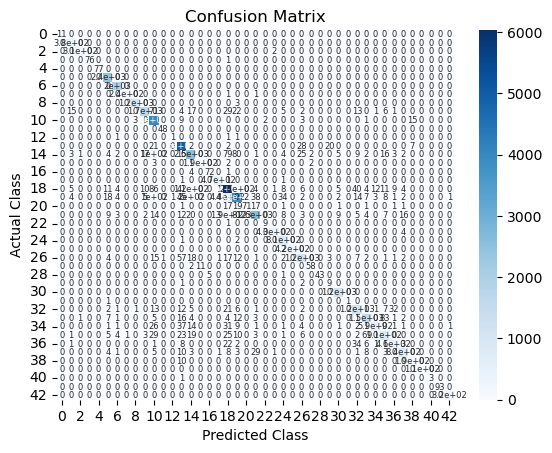

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cmx, annot=True, cmap="Blues", annot_kws={"size": 6})
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
#plt.figure(figsize=(20, 20))

<Figure size 3000x2000 with 0 Axes>

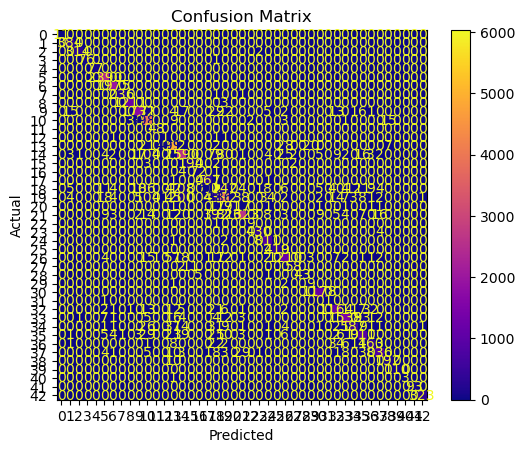

In [175]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cmx = confusion_matrix(test['pos_tag'], test['hyp'])
plt.figure(figsize=(30, 20))  
display = ConfusionMatrixDisplay(confusion_matrix=cmx)
display.plot(cmap='plasma', xticks_rotation='horizontal')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Given the confusion matrix, what are some common errors that your tagger makes?

By evaluating this Part Of Speech tagger using a Confusion Matrix, it is observed that the classifier has misclassified IN (Preposition or Subordinating Conjunction) to be as RP (Adverb Particle) with an error rate of about 62.5%. This could have occured due to certain words which can act as both a preposition and an adverb at the same time, such as 'out', 'on', 'in', etc.  Also, a misclassification of NNP as FW (Foreign Word) has occurred with an error rate of 50% (half of it). Here, in my opinion the Foreign Words are not properly categorised (mostly the words which do not constitute any meaning are mistook as foreign words) and also a proper noun can be easily identified if it were capitalized - but here the whole dataset is taken with small letters into consideration, so this becomes difficult to identify the same. Then, in a similar way around 23.9% of NNS (Singular Nouns) are misclassified as NNPS (Plural Proper Nouns). These were the common errors which the POS Tagger has made and been observed.
